In [1]:
!pip install pyjanitor
import janitor


[notice] A new release of pip available: 22.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Paso1: Importamos librerias
#!pip install pyjanitor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import janitor
import missingno

#Paso2: Ejecutamos pandas Missing extensión notebook
%run "D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_4\pandas_missing_extension.ipynb"

#Paso3: Cargamos dataset
data_df = pd.read_csv("D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_4\ecom_data.csv")
display(data_df.head(5))

#Paso4: EDA
display(data_df.dtypes)
display(data_df.dtypes.value_counts())
display(data_df.shape)
data_df.drop('CustomerID',axis=1,inplace=True) #eliminar CustomerID
display(data_df.head(5))

<>:14: DeprecationWarning: invalid escape sequence '\C'
<>:14: DeprecationWarning: invalid escape sequence '\C'
C:\Users\ingma\AppData\Local\Temp\ipykernel_14324\2351499269.py:14: DeprecationWarning: invalid escape sequence '\C'
  data_df = pd.read_csv("D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_4\ecom_data.csv")


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object

int64      8
float64    7
object     5
dtype: int64

(5630, 20)

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


número de datos faltantes


1856

None

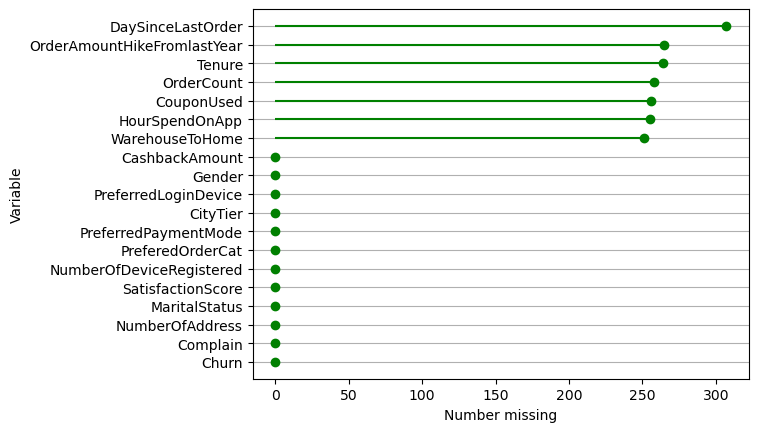

In [3]:
#Paso5:Tratamiento de datos faltantes
print("número de datos faltantes")
display(data_df.missing.number_missing())
display(data_df.missing.missing_variable_plot())

<Axes: >

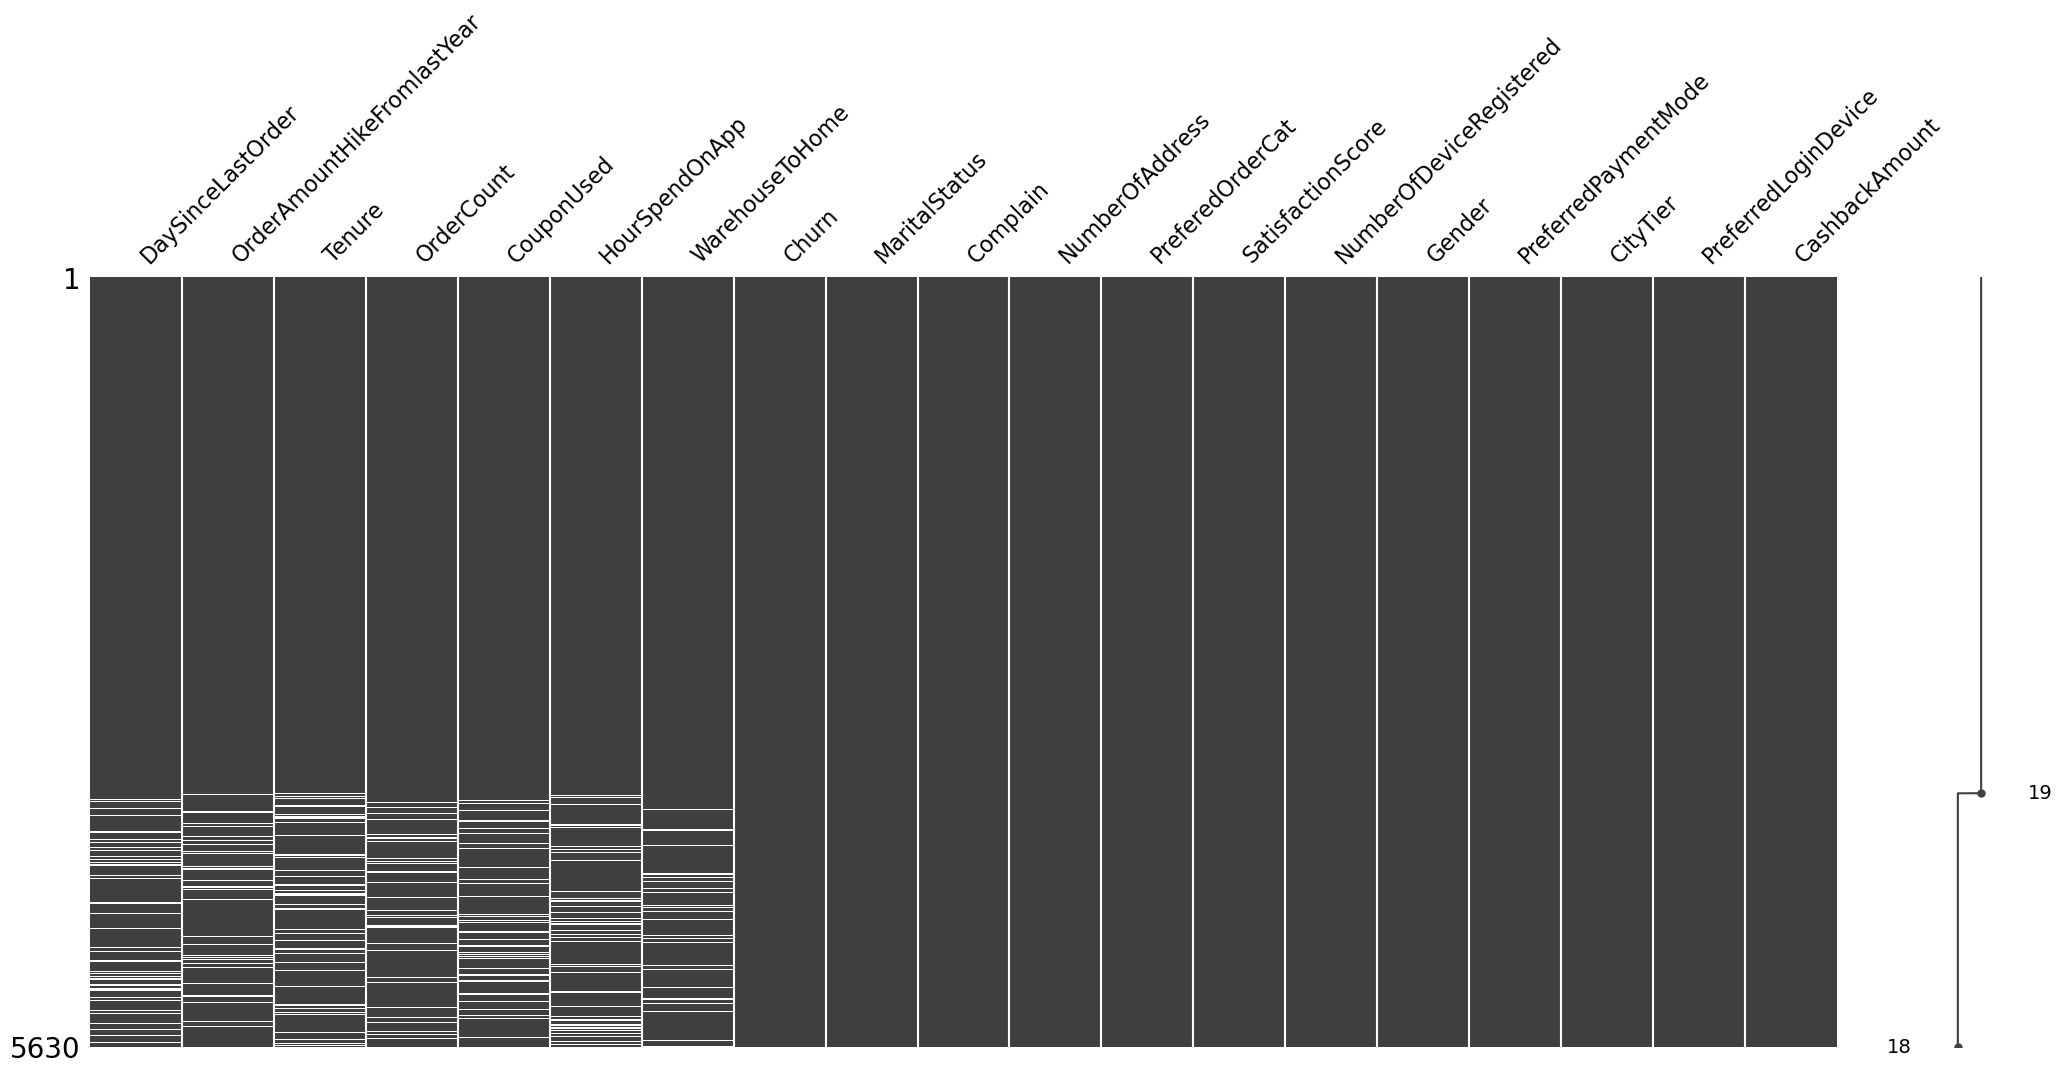

In [4]:
(
    data_df.missing.sort_variables_by_missingness()
    .pipe(
        missingno.matrix,sort='descending'
    )
)

In [5]:
#Cambiamos la nomenclatura de columnas
data_df_raw = (
    data_df.clean_names(
        case_type="snake"
    )
)
display(data_df_raw.head(5))
display(data_df_raw.info())

,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   churn                            5630 non-null   int64  
 1   tenure                           5366 non-null   float64
 2   preferred_login_device           5630 non-null   object 
 3   city_tier                        5630 non-null   int64  
 4   warehouse_to_home                5379 non-null   float64
 5   preferred_payment_mode           5630 non-null   object 
 6   gender                           5630 non-null   object 
 7   hour_spend_on_app                5375 non-null   float64
 8   number_of_device_registered      5630 non-null   int64  
 9   prefered_order_cat               5630 non-null   object 
 10  satisfaction_score               5630 non-null   int64  
 11  marital_status                   5630 non-null   object 
 12  number_of_address   

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   churn                            5630 non-null   int64  
 1   tenure                           5366 non-null   float64
 2   preferred_login_device           5630 non-null   object 
 3   city_tier                        5630 non-null   int64  
 4   warehouse_to_home                5379 non-null   float64
 5   preferred_payment_mode           5630 non-null   object 
 6   gender                           5630 non-null   object 
 7   hour_spend_on_app                5375 non-null   float64
 8   number_of_device_registered      5630 non-null   int64  
 9   prefered_order_cat               5630 non-null   object 
 10  satisfaction_score               5630 non-null   int64  
 11  marital_status                   5630 non-null   object 
 12  number_of_address   

None

Imputando en columna 'tenure' con promedio 10.189899366380917
Imputando en columna 'warehouse_to_home' con promedio 15.639895891429633
Imputando en columna 'hour_spend_on_app' con promedio 2.9315348837209303
Imputando en columna 'order_amount_hike_fromlast_year' con promedio 15.707921714818266
Imputando en columna 'coupon_used' con promedio 1.7510234462225531
Imputando en columna 'order_count' con promedio 3.0080044676098288
Imputando en columna 'day_since_last_order' con promedio 4.543490512868683

DataFrame resultante:


,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,1,4.000000,Mobile Phone,3,6.0,Debit Card,Female,3.000000,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,1,10.189899,Phone,1,8.0,UPI,Male,3.000000,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,1,10.189899,Phone,1,30.0,Debit Card,Male,2.000000,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,1,0.000000,Phone,3,15.0,Debit Card,Male,2.000000,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,1,0.000000,Phone,1,12.0,CC,Male,2.931535,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


0

None

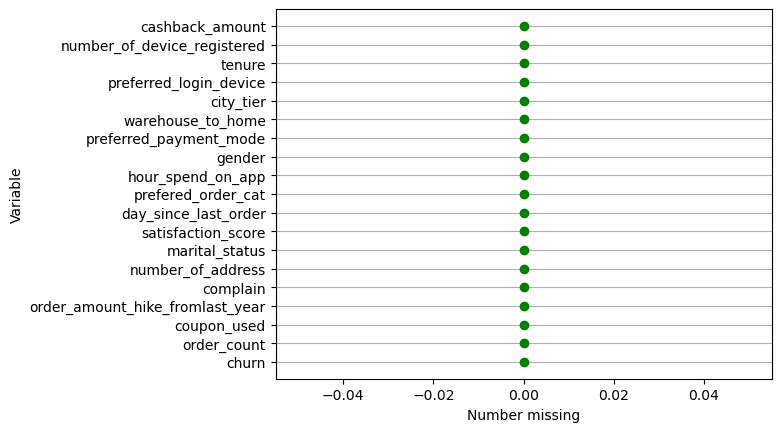

In [6]:
#Imputación de manera recursiva para el dataframe
df = data_df_raw.copy()
display(df.info())

# Aplicamos la función recursiva
df_imputado = imputar_recursivo(df.copy())

print("\nDataFrame resultante:")
display(df_imputado.head(5))
display(df_imputado.missing.number_missing())
display(df_imputado.missing.missing_variable_plot())

In [7]:
categorical_columns = df_imputado.select_dtypes(object).columns
categorical_columns

Index(['preferred_login_device', 'preferred_payment_mode', 'gender',
       'prefered_order_cat', 'marital_status'],
      dtype='object')

In [8]:
for cc in categorical_columns:
  print("*"*50)
  print(df_imputado[cc].value_counts())

**************************************************
Mobile Phone    2765
Computer        1634
Phone           1231
Name: preferred_login_device, dtype: int64
**************************************************
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: preferred_payment_mode, dtype: int64
**************************************************
Male      3384
Female    2246
Name: gender, dtype: int64
**************************************************
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: prefered_order_cat, dtype: int64
**************************************************
Married     2986
Single      1796
Divorced     848
Name: marital_status, dtype: int64


In [9]:
df_imputado

,churn,tenure,preferred_login_device,city_tier,warehouse_to_home,preferred_payment_mode,gender,hour_spend_on_app,number_of_device_registered,prefered_order_cat,satisfaction_score,marital_status,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,1,4.000000,Mobile Phone,3,6.0,Debit Card,Female,3.000000,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.000000,160
1,1,10.189899,Phone,1,8.0,UPI,Male,3.000000,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.000000,121
2,1,10.189899,Phone,1,30.0,Debit Card,Male,2.000000,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.000000,120
3,1,0.000000,Phone,3,15.0,Debit Card,Male,2.000000,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.000000,134
4,1,0.000000,Phone,1,12.0,CC,Male,2.931535,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.000000,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,10.000000,Computer,1,30.0,Credit Card,Male,3.000000,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.000000,151
5626,0,13.000000,Mobile Phone,1,13.0,Credit Card,Male,3.000000,5,Fashion,5,Married,6,0,16.0,1.0,2.0,4.543491,225
5627,0,1.000000,Mobile Phone,1,11.0,Debit Card,Male,3.000000,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.000000,186
5628,0,23.000000,Computer,3,9.0,Credit Card,Male,4.000000,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.000000,179


In [14]:
#Guardar archivo limpio
df.to_csv("D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_4\df_imputado.csv", index=False, encoding='utf-8')

<>:2: DeprecationWarning: invalid escape sequence '\C'
<>:2: DeprecationWarning: invalid escape sequence '\C'
C:\Users\ingma\AppData\Local\Temp\ipykernel_14324\1259618204.py:2: DeprecationWarning: invalid escape sequence '\C'
  df.to_csv("D:\Conocimiento Adquiridos\Data Science _ Codigo Bootcamp\Desarrollo_MP\BDS-G3\Dia_4\df_imputado.csv", index=False, encoding='utf-8')


In [15]:
#Seleccionar columna ordinal  - onehot
ordinal_cols = ['gender']
onehot_cols = list(set(categorical_columns) - set(ordinal_cols))
onehot_cols

['marital_status',
 'prefered_order_cat',
 'preferred_login_device',
 'preferred_payment_mode']

In [16]:
import sklearn.compose
import sklearn.preprocessing
transformer = sklearn.compose.make_column_transformer(
    (sklearn.preprocessing.OrdinalEncoder(),ordinal_cols),
    (sklearn.preprocessing.OneHotEncoder(),onehot_cols),
    remainder='passthrough'
)
transformer

ColumnTransformer(remainder='passthrough',
                  transformers=[('ordinalencoder', OrdinalEncoder(),
                                 ['gender']),
                                ('onehotencoder', OneHotEncoder(),
                                 ['marital_status', 'prefered_order_cat',
                                  'preferred_login_device',
                                  'preferred_payment_mode'])])

In [17]:
data_transformed_df = (
    pd.DataFrame(
        transformer.fit_transform(df_imputado),
        columns = transformer.get_feature_names_out(),
        index=df_imputado.index
    )
)

data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("ordinalencoder__", "").replace("onehotencoder__", "").replace("remainder__", "")
)

data_transformed_df

,gender,marital_status_Divorced,marital_status_Married,marital_status_Single,prefered_order_cat_Fashion,prefered_order_cat_Grocery,prefered_order_cat_Laptop & Accessory,prefered_order_cat_Mobile,prefered_order_cat_Mobile Phone,prefered_order_cat_Others,...,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.000000,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.000000,160.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.000000,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.000000,121.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.000000,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.000000,120.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.000000,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.000000,134.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.931535,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.000000,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.000000,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.000000,151.0
5626,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.000000,5.0,5.0,6.0,0.0,16.0,1.0,2.0,4.543491,225.0
5627,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.000000,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.000000,186.0
5628,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.000000,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.000000,179.0


In [18]:
data_transformed_df = (
    data_transformed_df.clean_names(
        case_type="snake"
    )
)
data_transformed_df.columns

Index(['gender', 'marital_status_divorced', 'marital_status_married',
       'marital_status_single', 'prefered_order_cat_fashion',
       'prefered_order_cat_grocery', 'prefered_order_cat_laptop_&_accessory',
       'prefered_order_cat_mobile', 'prefered_order_cat_mobile_phone',
       'prefered_order_cat_others', 'preferred_login_device_computer',
       'preferred_login_device_mobile_phone', 'preferred_login_device_phone',
       'preferred_payment_mode_cc', 'preferred_payment_mode_cod',
       'preferred_payment_mode_cash_on_delivery',
       'preferred_payment_mode_credit_card',
       'preferred_payment_mode_debit_card', 'preferred_payment_mode_e_wallet',
       'preferred_payment_mode_upi', 'churn', 'tenure', 'city_tier',
       'warehouse_to_home', 'hour_spend_on_app', 'number_of_device_registered',
       'satisfaction_score', 'number_of_address', 'complain',
       'order_amount_hike_fromlast_year', 'coupon_used', 'order_count',
       'day_since_last_order', 'cashback_amount

In [19]:
data_transformed_df = data_transformed_df.rename(
    columns=lambda x: x.replace("prefered_order_cat_", "order_").replace("preferred_payment_mode_", "payment_").replace("preferred_login_device_", "login_").replace("marital_status_", "")
)
data_transformed_df

,gender,divorced,married,single,order_fashion,order_grocery,order_laptop_&_accessory,order_mobile,order_mobile_phone,order_others,...,hour_spend_on_app,number_of_device_registered,satisfaction_score,number_of_address,complain,order_amount_hike_fromlast_year,coupon_used,order_count,day_since_last_order,cashback_amount
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.000000,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.000000,160.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.000000,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.000000,121.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.000000,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.000000,120.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.000000,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.000000,134.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.931535,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.000000,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.000000,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.000000,151.0
5626,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.000000,5.0,5.0,6.0,0.0,16.0,1.0,2.0,4.543491,225.0
5627,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.000000,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.000000,186.0
5628,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.000000,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.000000,179.0


In [20]:
data_transformed_df = data_transformed_df.rename(
    columns={
        "order_laptop_&_accessory":"order_laptop",
        "order_mobile":"order_phone",
        "payment_cash_on_delivery":"payment_cash",
        "payment_credit_card":"payment_credit",
        "payment_debit_card":"payment_debit",
        "payment_e_wallet":"payment_ewallet",
        "login_mobile_phone":"login_mobile",
        "warehouse_to_home":"distance",
        "hour_spend_on_app":"hour_spend",
        "number_of_device_registered":"device_registered",
        "number_of_address":"number_address",
        "order_amount_hike_fromlast_year":"order_lastyear",
        "day_since_last_order":"days_lastorder"
    }
)
data_transformed_df.columns

Index(['gender', 'divorced', 'married', 'single', 'order_fashion',
       'order_grocery', 'order_laptop', 'order_phone', 'order_mobile_phone',
       'order_others', 'login_computer', 'login_mobile', 'login_phone',
       'payment_cc', 'payment_cod', 'payment_cash', 'payment_credit',
       'payment_debit', 'payment_ewallet', 'payment_upi', 'churn', 'tenure',
       'city_tier', 'distance', 'hour_spend', 'device_registered',
       'satisfaction_score', 'number_address', 'complain', 'order_lastyear',
       'coupon_used', 'order_count', 'days_lastorder', 'cashback_amount'],
      dtype='object')

In [21]:
data_transformed_df

,gender,divorced,married,single,order_fashion,order_grocery,order_laptop,order_phone,order_mobile_phone,order_others,...,hour_spend,device_registered,satisfaction_score,number_address,complain,order_lastyear,coupon_used,order_count,days_lastorder,cashback_amount
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.000000,3.0,2.0,9.0,1.0,11.0,1.0,1.0,5.000000,160.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,3.000000,4.0,3.0,7.0,1.0,15.0,0.0,1.0,0.000000,121.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.000000,4.0,3.0,6.0,1.0,14.0,0.0,1.0,3.000000,120.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.000000,4.0,5.0,8.0,0.0,23.0,0.0,1.0,3.000000,134.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,2.931535,3.0,5.0,3.0,0.0,11.0,1.0,1.0,3.000000,130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.000000,2.0,1.0,6.0,0.0,18.0,1.0,2.0,4.000000,151.0
5626,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,3.000000,5.0,5.0,6.0,0.0,16.0,1.0,2.0,4.543491,225.0
5627,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,3.000000,2.0,4.0,3.0,1.0,21.0,1.0,2.0,4.000000,186.0
5628,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.000000,5.0,4.0,4.0,0.0,15.0,2.0,2.0,9.000000,179.0


In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_transformed_df)
data_scaled

array([[0.        , 0.        , 0.        , ..., 0.        , 0.10869565,
        0.49230769],
       [1.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.37230769],
       [1.        , 0.        , 0.        , ..., 0.        , 0.06521739,
        0.36923077],
       ...,
       [1.        , 0.        , 1.        , ..., 0.06666667, 0.08695652,
        0.57230769],
       [1.        , 0.        , 1.        , ..., 0.06666667, 0.19565217,
        0.55076923],
       [1.        , 0.        , 1.        , ..., 0.06666667, 0.06521739,
        0.52      ]])

In [23]:
data_scaled_df = pd.DataFrame(data_scaled)
data_scaled_df.columns = data_transformed_df.columns
data_scaled_df

,gender,divorced,married,single,order_fashion,order_grocery,order_laptop,order_phone,order_mobile_phone,order_others,...,hour_spend,device_registered,satisfaction_score,number_address,complain,order_lastyear,coupon_used,order_count,days_lastorder,cashback_amount
0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.600000,0.4,0.25,0.380952,1.0,0.000000,0.0625,0.000000,0.108696,0.492308
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.600000,0.6,0.50,0.285714,1.0,0.266667,0.0000,0.000000,0.000000,0.372308
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.400000,0.6,0.50,0.238095,1.0,0.200000,0.0000,0.000000,0.065217,0.369231
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.400000,0.6,1.00,0.333333,0.0,0.800000,0.0000,0.000000,0.065217,0.412308
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.586307,0.4,1.00,0.095238,0.0,0.000000,0.0625,0.000000,0.065217,0.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.600000,0.2,0.00,0.238095,0.0,0.466667,0.0625,0.066667,0.086957,0.464615
5626,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.600000,0.8,1.00,0.238095,0.0,0.333333,0.0625,0.066667,0.098772,0.692308
5627,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.600000,0.2,0.75,0.095238,1.0,0.666667,0.0625,0.066667,0.086957,0.572308
5628,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.800000,0.8,0.75,0.142857,0.0,0.266667,0.1250,0.066667,0.195652,0.550769


In [24]:
corr_matrix = data_scaled_df.corr()
corr_churn = corr_matrix['churn']
corr_churn.sort_values(ascending=False)

churn                 1.000000
complain              0.250188
single                0.180847
order_mobile_phone    0.154387
order_phone           0.113364
device_registered     0.107939
satisfaction_score    0.105481
city_tier             0.084703
payment_cod           0.083933
login_phone           0.078916
distance              0.073497
payment_ewallet       0.055751
login_computer        0.051099
number_address        0.043931
gender                0.029264
payment_cc            0.028796
hour_spend            0.018126
payment_upi           0.004163
payment_cash         -0.006178
coupon_used          -0.008197
order_lastyear       -0.009949
order_fashion        -0.014871
divorced             -0.024934
order_count          -0.028342
payment_debit        -0.032453
order_others         -0.054903
payment_credit       -0.064131
order_grocery        -0.089575
login_mobile         -0.111639
order_laptop         -0.133353
married              -0.151024
cashback_amount      -0.154161
days_las

<Axes: >

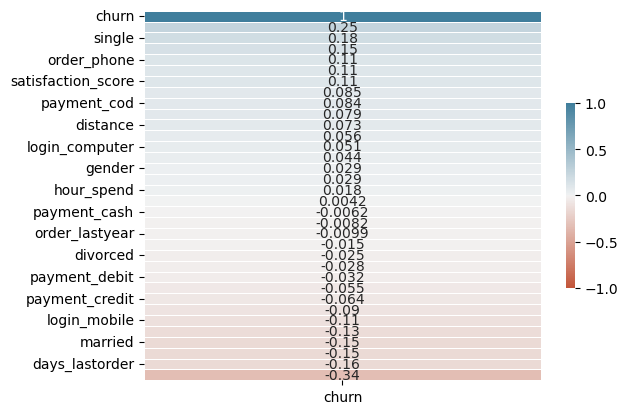

In [25]:
sns.heatmap(
    data=corr_churn.sort_values(ascending=False).to_frame(),
    cmap=sns.diverging_palette(20, 230, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    annot=True
)

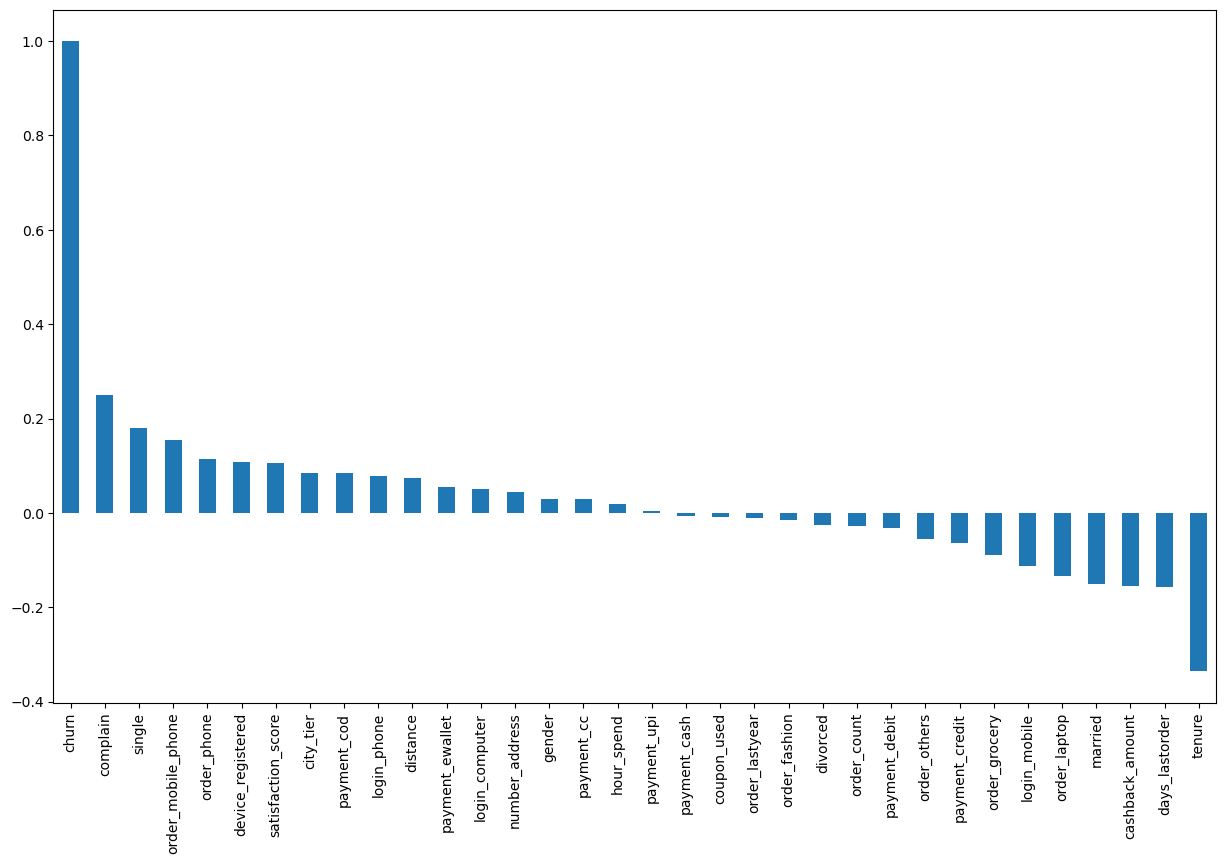

In [26]:
fig = plt.figure(figsize=(15,9))
data_scaled_df.corr()['churn'].sort_values(ascending=False).plot(kind='bar')
plt.show()

In [27]:
#Elegir las variables con mayor correlación
corr_filtered = corr_churn[corr_churn > 0.10]
cols = corr_filtered.index.tolist()
cols

['single',
 'order_phone',
 'order_mobile_phone',
 'churn',
 'device_registered',
 'satisfaction_score',
 'complain']

In [28]:
df_data_scaled_for_train = data_transformed_df[cols].copy()
df_data_scaled_for_train.head(5)

,single,order_phone,order_mobile_phone,churn,device_registered,satisfaction_score,complain
0,1.0,0.0,0.0,1.0,3.0,2.0,1.0
1,1.0,1.0,0.0,1.0,4.0,3.0,1.0
2,1.0,1.0,0.0,1.0,4.0,3.0,1.0
3,1.0,0.0,0.0,1.0,4.0,5.0,0.0
4,1.0,1.0,0.0,1.0,3.0,5.0,0.0


In [29]:
X = df_data_scaled_for_train.drop('churn',axis=1)
y = df_data_scaled_for_train['churn'].values

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [31]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=500)
result = model.fit(X_train,y_train)

In [32]:
from sklearn import metrics
y_pred = model.predict(X_test)
print(f'accuracy : {metrics.accuracy_score(y_test,y_pred)}')

accuracy : 0.8490230905861457


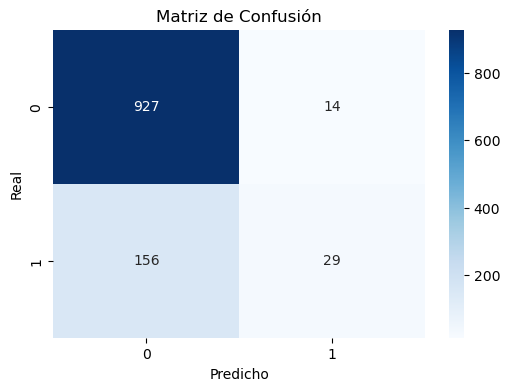

In [33]:
conf_matrix = metrics.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()